In [1]:
!pip install ultralytics roboflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 74.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.3/260.3 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 77.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 133.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
httpx2 2.4.0 requires idna>=3.18, but you have idna 3.7 which is incompatible.


In [2]:
from roboflow import Roboflow
from google.colab import userdata
from IPython.display import Image

In [3]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [4]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets

ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

project = rf.workspace("roboflow-jvuqo").project("football-players-detection-3zvbc")
version = project.version(20)
dataset = version.download("yolo26")

/content/datasets
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to football-players-detection-20 in yolo26:: 100%|██████████| 756/756 [00:00<00:00, 7582.73it/s]


In [5]:
import ultralytics
print(ultralytics.__version__)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
8.4.84


In [6]:
!sed -i 's|\(train: \).*|\1../train/images|' {dataset.location}/data.yaml
!sed -i 's|\(val: \).*|\1../valid/images|' {dataset.location}/data.yaml

In [7]:
%cd {HOME}

!yolo task=detect mode=train model=yolo26x.pt data={dataset.location}/data.yaml batch=3 epochs=100 patience=20 imgsz=1280 close_mosaic=15 cos_lr=True cache=True plots=True

/content
Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=3, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/datasets/football-players-detection-20/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26x.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimiz

In [8]:
!ls {HOME}/runs/detect/train/

args.yaml			 labels.jpg		val_batch0_pred.jpg
BoxF1_curve.png			 results.csv		val_batch1_labels.jpg
BoxP_curve.png			 results.png		val_batch1_pred.jpg
BoxPR_curve.png			 train_batch0.jpg	val_batch2_labels.jpg
BoxR_curve.png			 train_batch1.jpg	val_batch2_pred.jpg
confusion_matrix_normalized.png  train_batch2.jpg	weights
confusion_matrix.png		 val_batch0_labels.jpg


/content


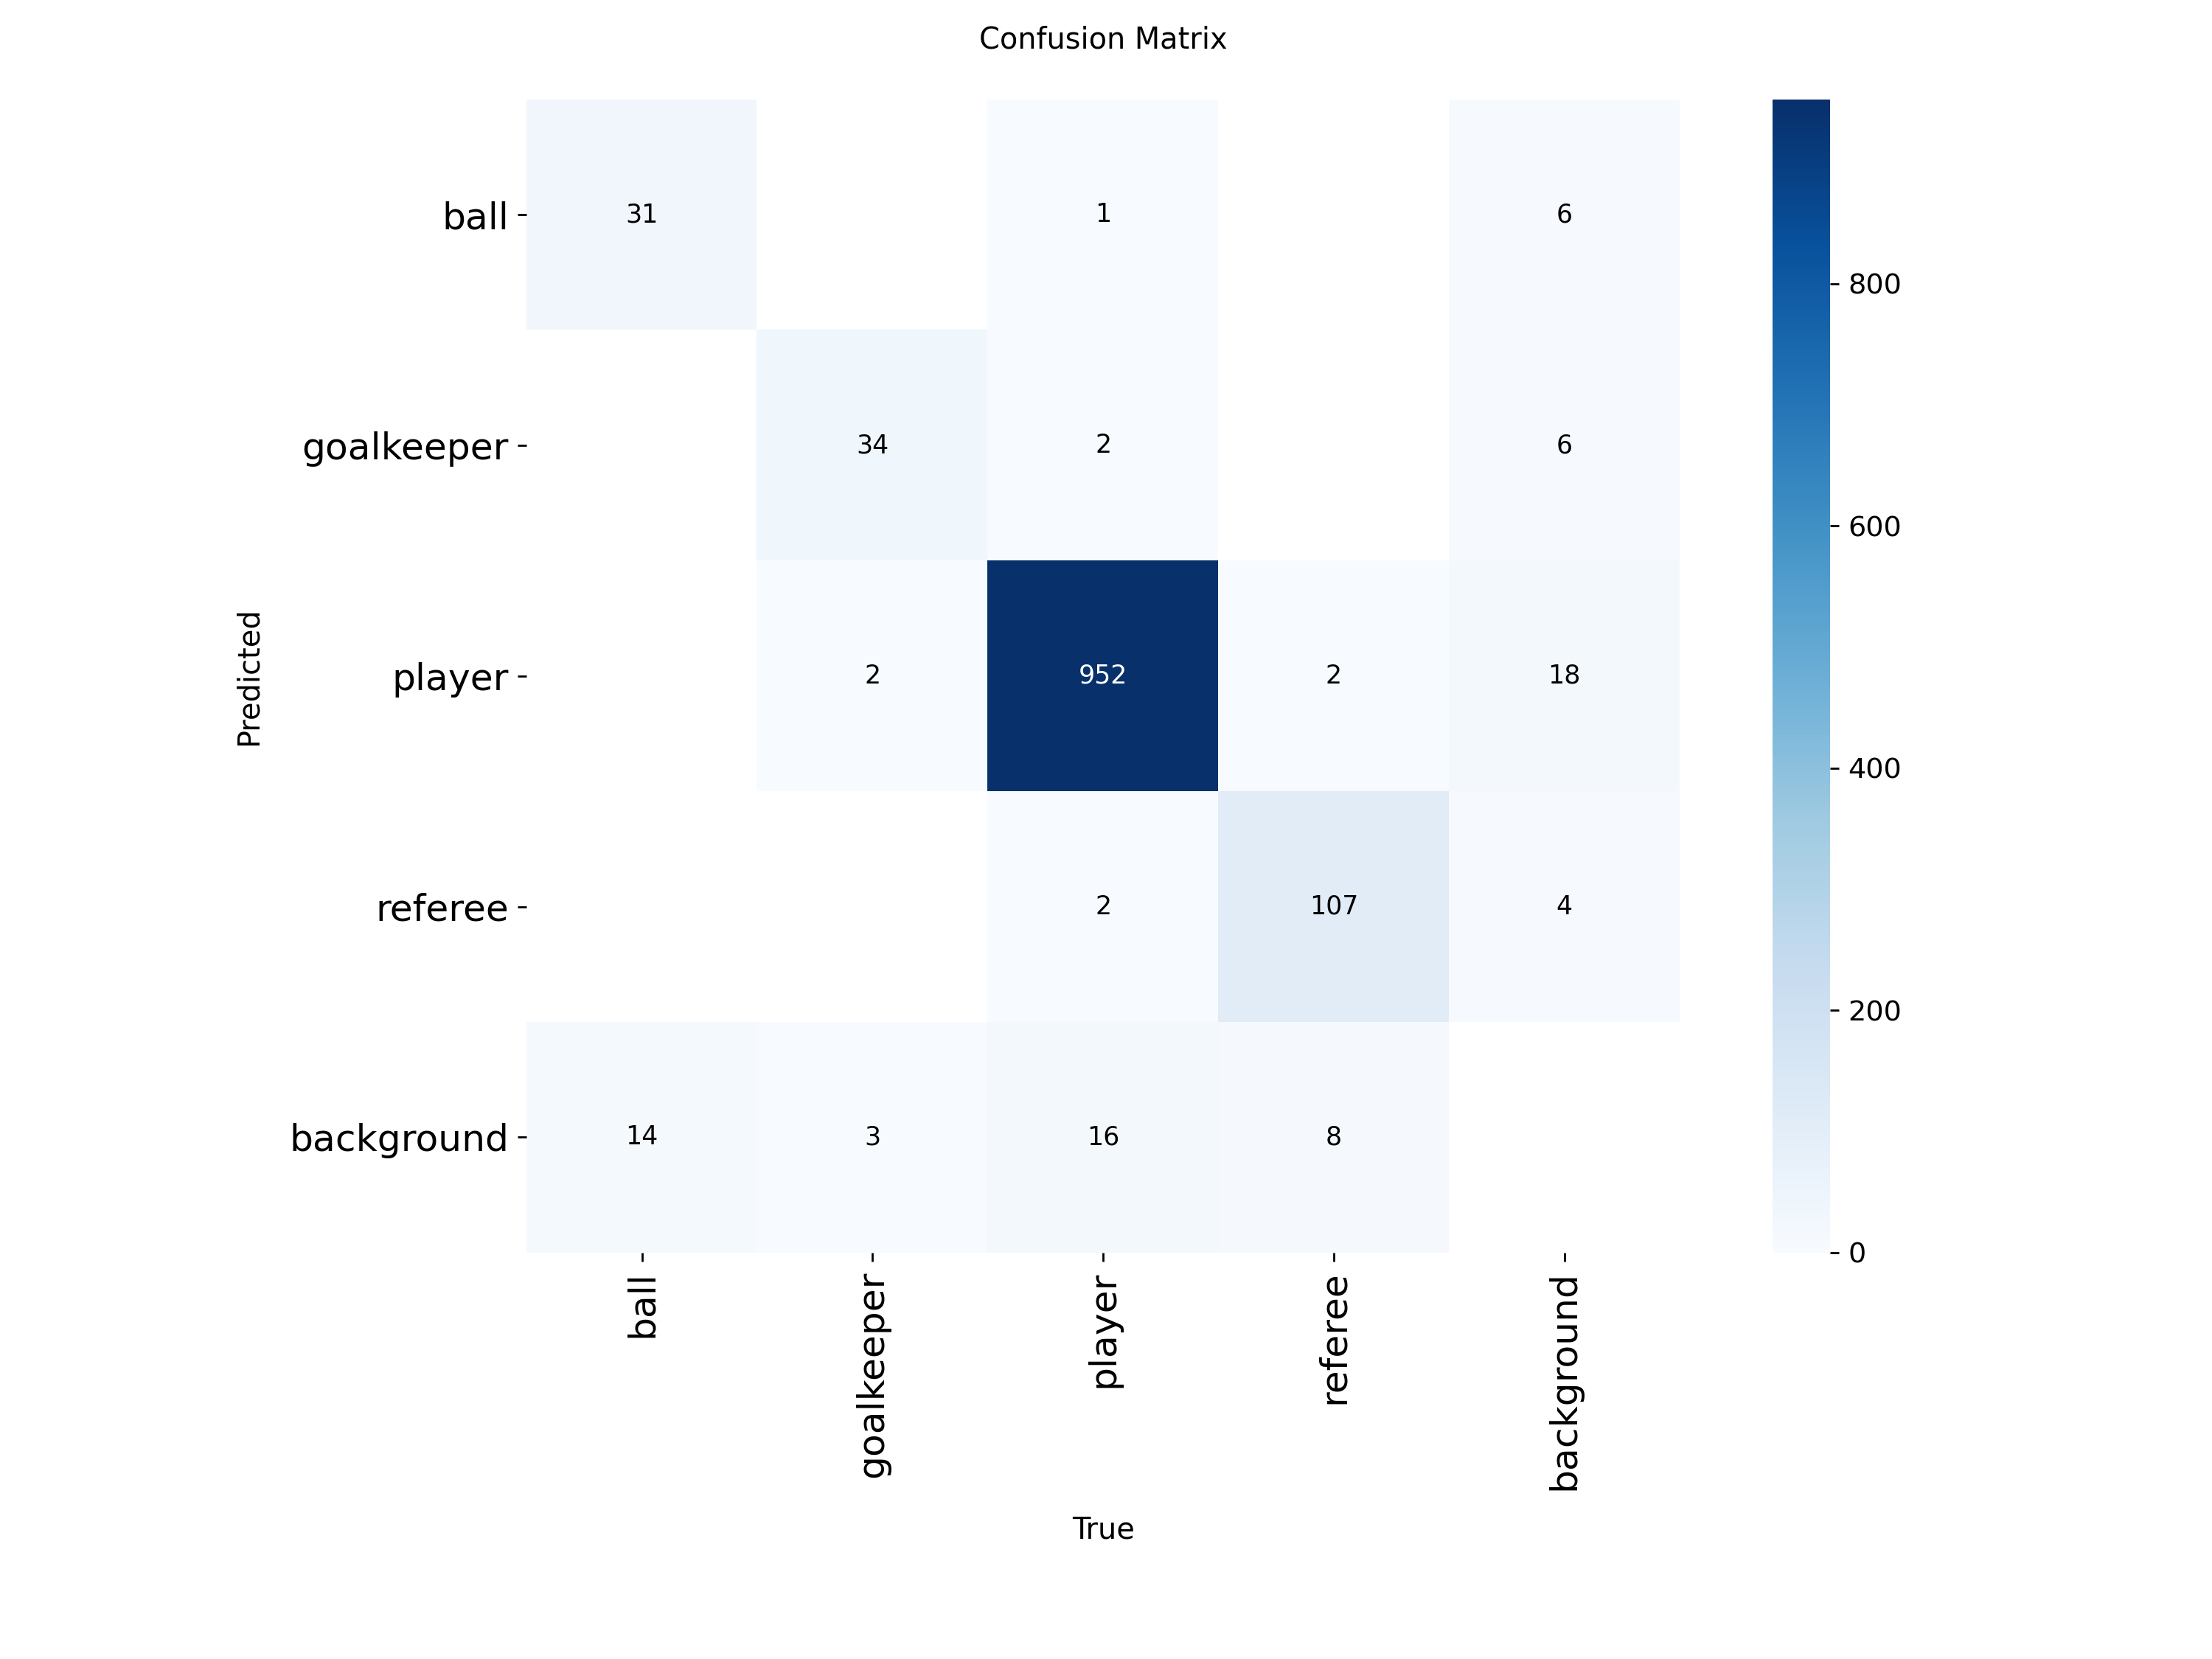

In [24]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/confusion_matrix.png')

/content


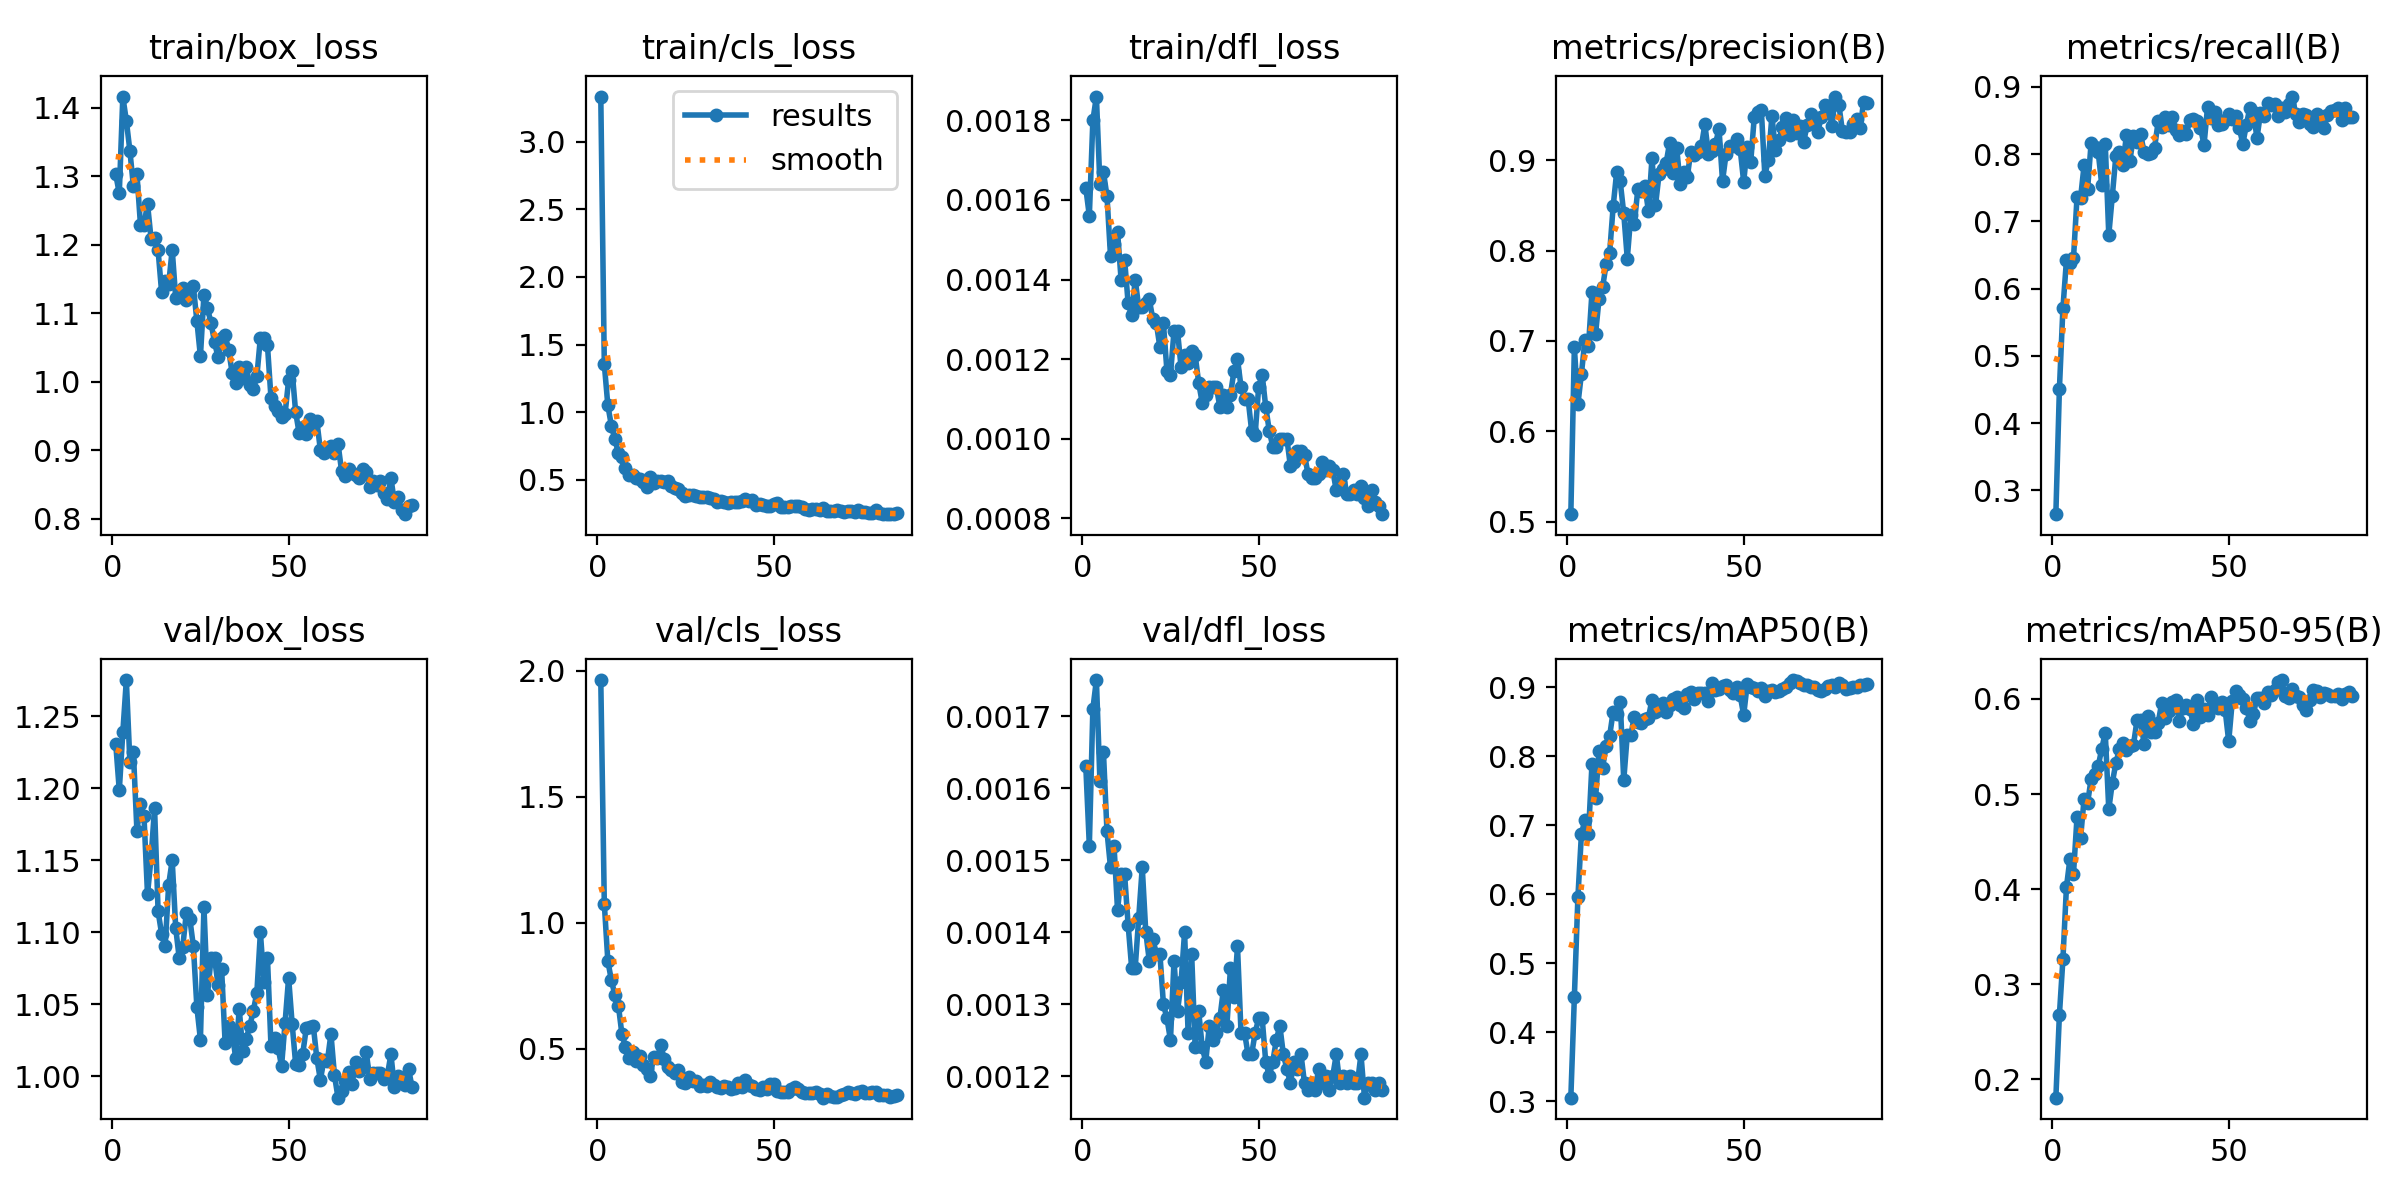

In [23]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/results.png')

/content


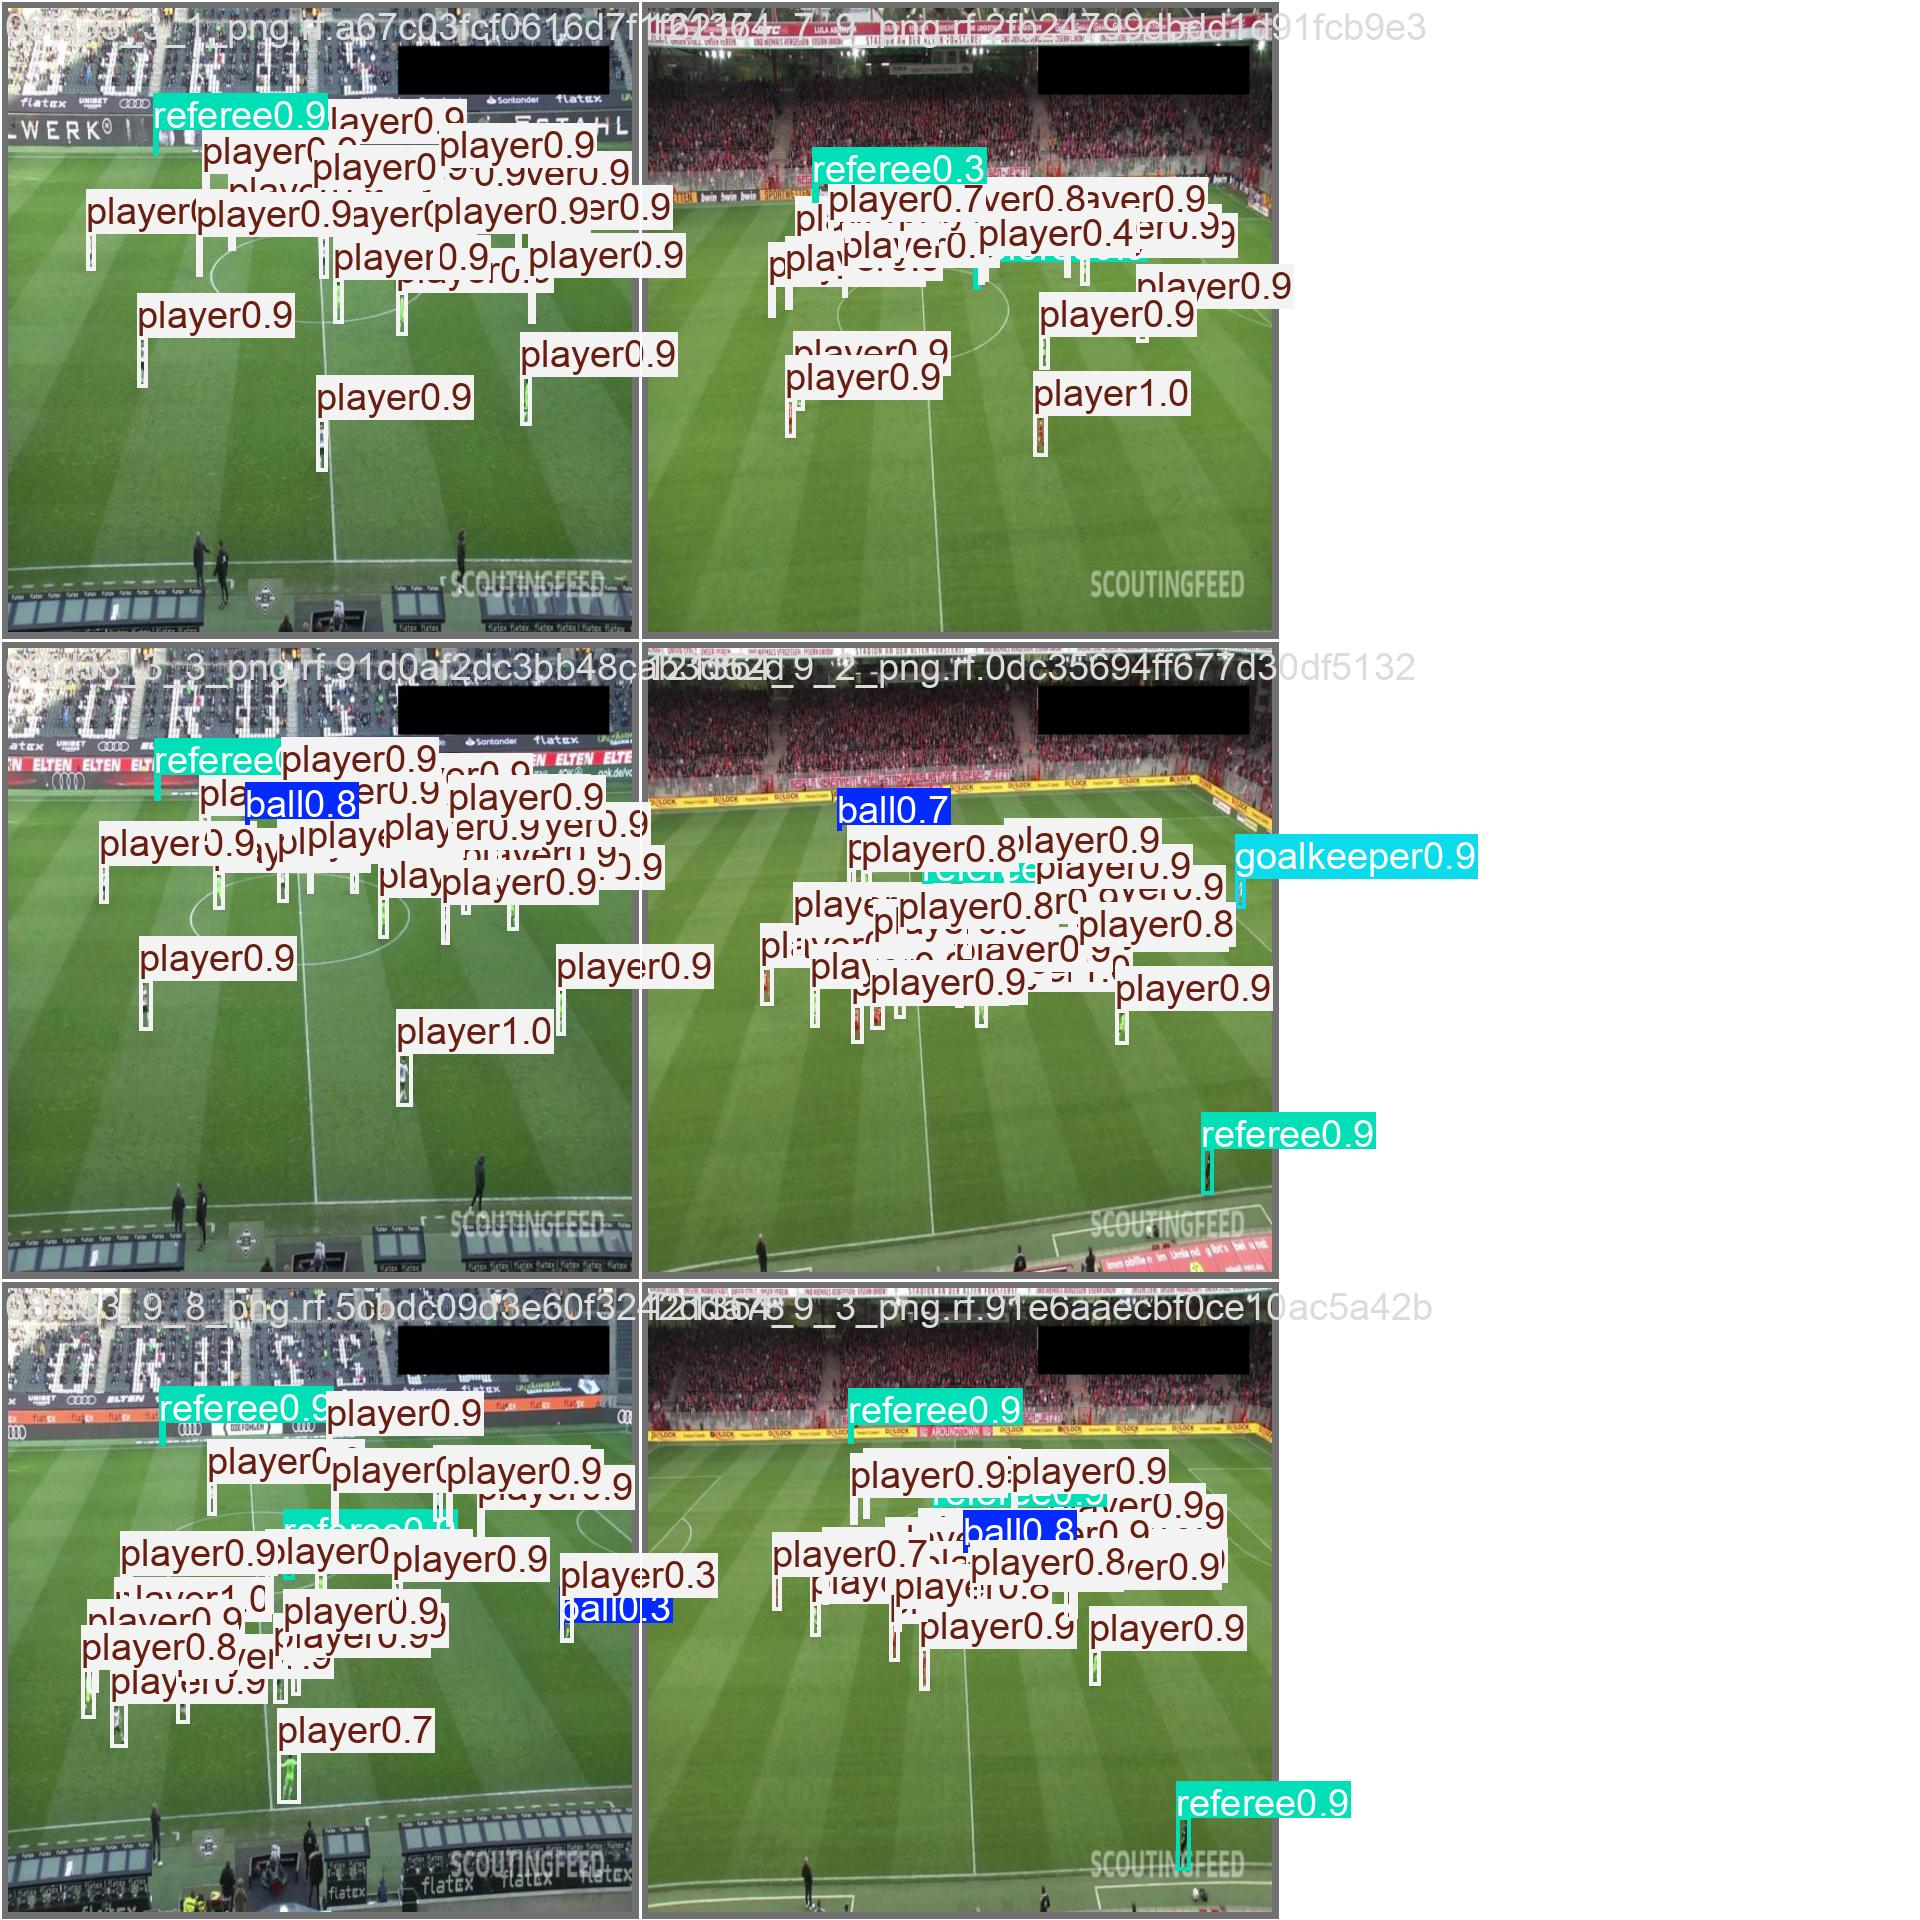

In [11]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=600)

In [12]:
%cd {HOME}

!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml imgsz=1280

/content
Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26x summary (fused): 190 layers, 55,638,168 parameters, 0 gradients, 193.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 37.1±6.1 MB/s, size: 50.8 KB)
val: Scanning /content/datasets/football-players-detection-20/valid/labels.cache... 49 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 49/49 6.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 5.0s/it 20.2s
                   all         49       1174       0.93      0.867      0.909      0.624
                  ball         45         45      0.919      0.689      0.733       0.37
            goalkeeper         38         39      0.855      0.905       0.94      0.713
                player         49        973      0.983      0.974      0.993       0.76
               referee         49        117      0.963      0.901      0.971      0.652
Speed: 27.5m

In [22]:
project.version(dataset.version).deploy(model_type="yolo26", model_path=f"{HOME}/runs/detect/train/")

An error occured when getting the model upload URL: 404 Client Error: Not Found for url: https://api.roboflow.com/roboflow-jvuqo/football-players-detection-3zvbc/20/uploadModel?api_key=lNwnkxtqlQl99XZfqPyg&modelType=yolo26&nocache=true


In [27]:
!zip -r runs.zip /content/runs/detect/

updating: content/runs/detect/ (stored 0%)
  adding: content/runs/detect/val/ (stored 0%)
  adding: content/runs/detect/val/val_batch1_pred.jpg (deflated 1%)
  adding: content/runs/detect/val/BoxR_curve.png (deflated 10%)
  adding: content/runs/detect/val/BoxF1_curve.png (deflated 9%)
  adding: content/runs/detect/val/val_batch0_labels.jpg (deflated 1%)
  adding: content/runs/detect/val/val_batch1_labels.jpg (deflated 1%)
  adding: content/runs/detect/val/val_batch0_pred.jpg (deflated 1%)
  adding: content/runs/detect/val/confusion_matrix_normalized.png (deflated 24%)
  adding: content/runs/detect/val/BoxP_curve.png (deflated 13%)
  adding: content/runs/detect/val/val_batch2_pred.jpg (deflated 1%)
  adding: content/runs/detect/val/val_batch2_labels.jpg (deflated 1%)
  adding: content/runs/detect/val/confusion_matrix.png (deflated 28%)
  adding: content/runs/detect/val/BoxPR_curve.png (deflated 16%)
  adding: content/runs/detect/train/ (stored 0%)
  adding: content/runs/detect/train/val